# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  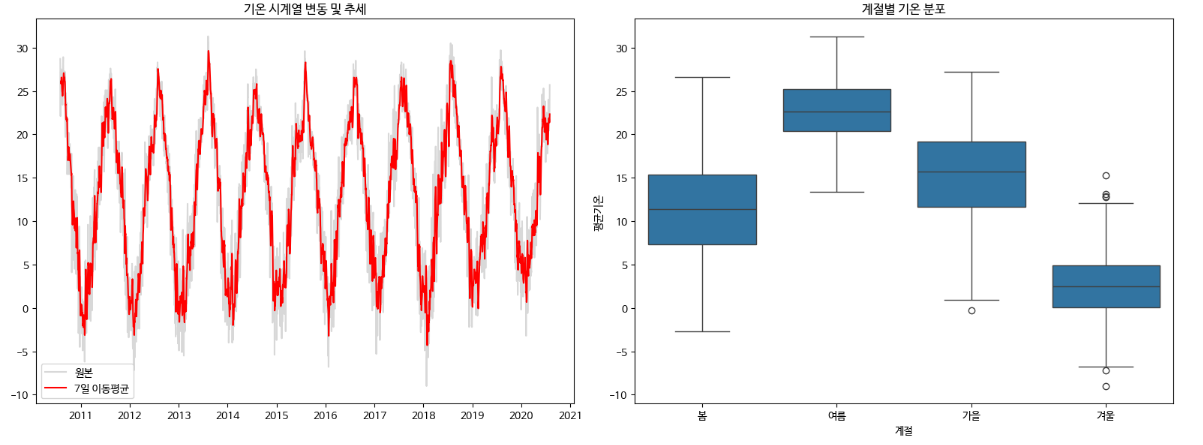

  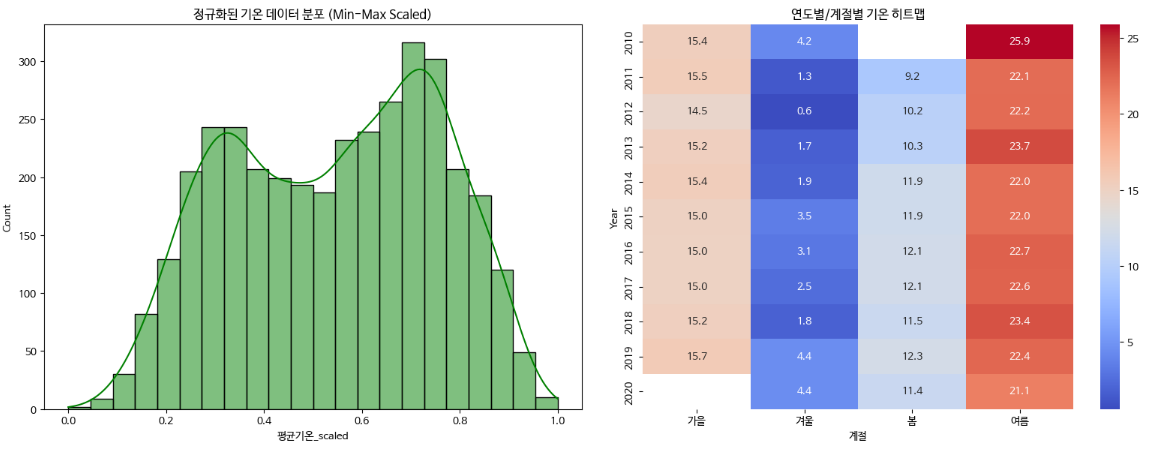



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

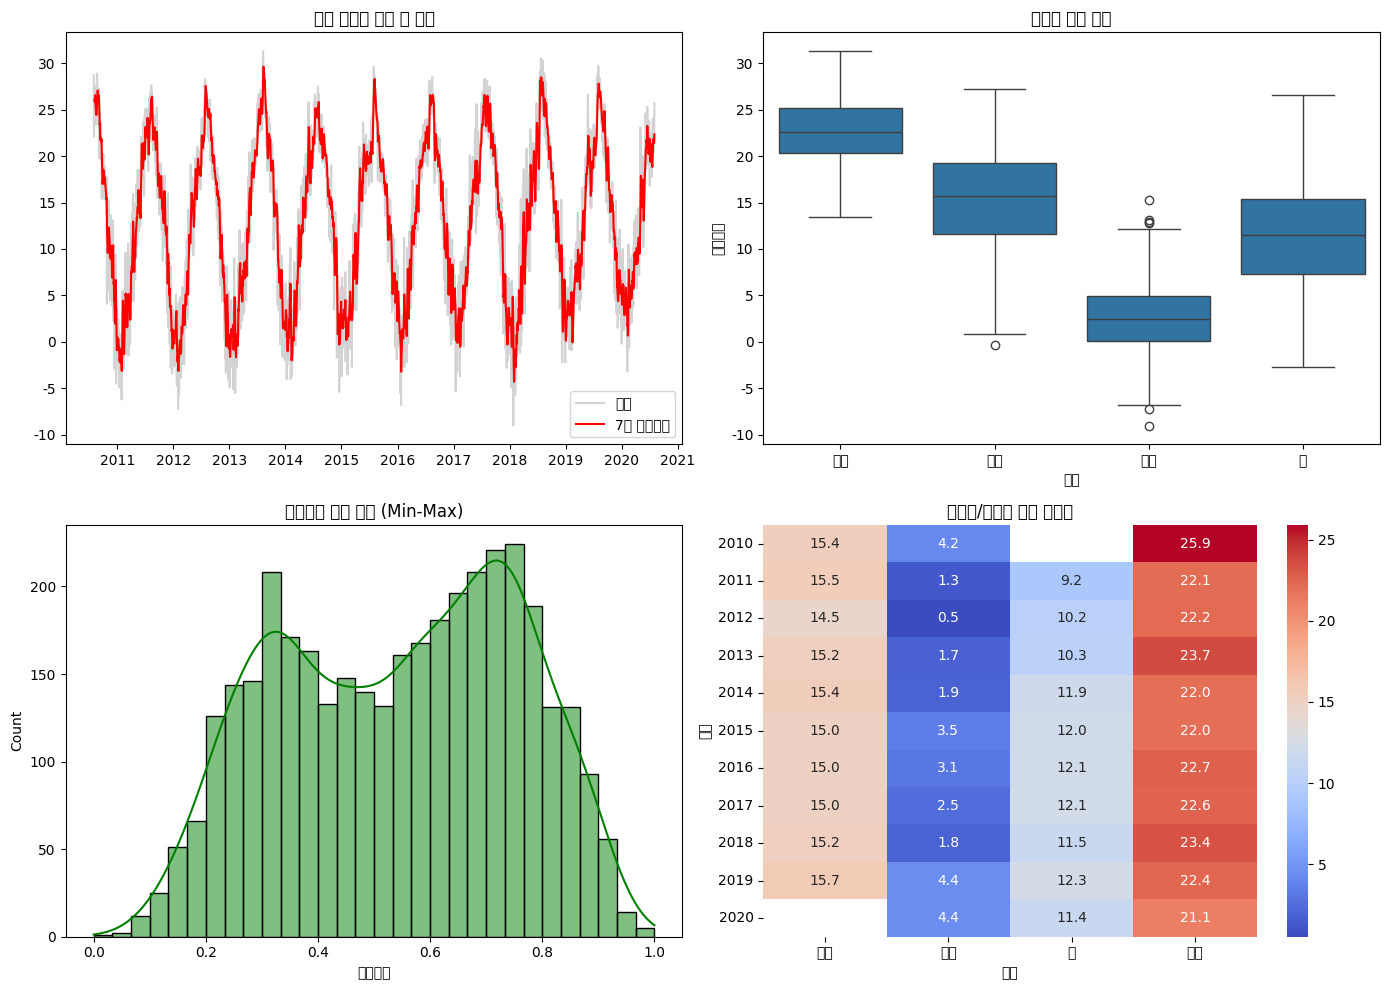

✔ 분석 완료 & 엑셀 저장 완료!


In [2]:
# ==============================
# 1. 라이브러리
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정   (교수님이 수업에서 알려주신 한글꺠짐 방지 코드를 사용했지만 쟤가 할 때마다 오류가 떠서 어쩔 수 없이 인터넷에서 쓰는 한글깨짐 방지 코드를 썼습니다...죄송합니다ㅠㅠ)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


# ==============================
# 2. 데이터 로드
# ==============================
def load_data(url):
    try:
        df = pd.read_csv(url, encoding='cp949')  # -> (이 부분도 제가 도저히 오류를 못고쳐서 인터넷에서 보고 코드를 썼습니다...죄송합니다ㅠㅠ)
    except:
        try:
            df = pd.read_csv(url, encoding='euc-kr')
        except:
            df = pd.read_csv(url, encoding='utf-8')
    return df


# ==============================
# 3. 전처리
# ==============================
def preprocess_data(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df.set_index('일시', inplace=True)

    df = df[['평균기온', '최대풍속', '평균풍속']]
    df = df.dropna()

    return df


# ==============================
# 4. Min-Max 정규화
# ==============================
def min_max_scaling(series):
    return (series - series.min()) / (series.max() - series.min())


# ==============================
# 5. 이동 평균
# ==============================
def add_moving_average(df, window=7):
    df['7일이동평균'] = df['평균기온'].rolling(window=window).mean()
    return df


# ==============================
# 6. 계절/연도 컬럼
# ==============================
def add_season_column(df):
    def get_season(month):
        if month in [3,4,5]:
            return '봄'
        elif month in [6,7,8]:
            return '여름'
        elif month in [9,10,11]:
            return '가을'
        else:
            return '겨울'

    df['계절'] = df.index.month.map(get_season)
    df['연도'] = df.index.year

    return df


# ==============================
# 7. 계절 통계
# ==============================
def seasonal_statistics(df):
    return df.groupby('계절')['평균기온'].describe()


# ==============================
# 8. 피벗 테이블
# ==============================
def create_pivot_table(df):
    pivot = pd.pivot_table(
        df,
        values='평균기온',
        index='연도',
        columns='계절',
        aggfunc='mean'
    )
    return pivot


# ==============================
# 9. 시각화
# ==============================
def visualize(df, pivot):
    plt.figure(figsize=(14,10))

    # (1) 시계열 + 이동평균
    plt.subplot(2,2,1)
    plt.plot(df.index, df['평균기온'], color='lightgray', label='원본')
    plt.plot(df.index, df['7일이동평균'], color='red', label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.legend()

    # (2) 계절별 박스플롯
    plt.subplot(2,2,2)
    sns.boxplot(x='계절', y='평균기온', data=df)
    plt.title('계절별 기온 분포')

    # (3) 정규화 히스토그램
    plt.subplot(2,2,3)
    scaled = min_max_scaling(df['평균기온'])
    sns.histplot(scaled, bins=30, kde=True, color='green')
    plt.title('정규화된 기온 분포 (Min-Max)')

    # (4) 히트맵
    plt.subplot(2,2,4)
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm')
    plt.title('연도별/계절별 기온 히트맵')

    plt.tight_layout()
    plt.show()


# ==============================
# 10. 엑셀 저장
# ==============================
def save_to_excel(df, seasonal_stats, pivot):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='전처리데이터')
        seasonal_stats.to_excel(writer, sheet_name='계절통계')
        pivot.to_excel(writer, sheet_name='피벗테이블')


# ==============================
# 11. 메인   -> (이 부분도 오류를 못고친 이유로 인터넷을 참고하여 고쳤습니다...죄송합니다ㅠㅠ)
# ==============================
def main():
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    df = load_data(url)
    df = preprocess_data(df)
    df = add_moving_average(df)
    df = add_season_column(df)

    seasonal_stats = seasonal_statistics(df)
    pivot = create_pivot_table(df)

    visualize(df, pivot)
    save_to_excel(df, seasonal_stats, pivot)

    print("✔ 분석 완료 & 엑셀 저장 완료!")


# ==============================
# 실행
# ==============================
if __name__ == "__main__":
    main()